# ASiT experiments

complete_asit_001 ['version_0']
  Loaded version_0: 2540 rows
  Combined: 2540 rows
asit_supervised_001 ['version_0']
  Loaded version_0: 6350 rows
  Combined: 6350 rows
asit_supervised_002 ['version_0']
  Loaded version_0: 1544 rows
  Combined: 1544 rows
asit_supervised_003 ['version_0']
  Loaded version_0: 1131 rows
  Combined: 1131 rows
asit_supervised_004 ['version_0']
  Loaded version_0: 873 rows
  Combined: 873 rows
asit_supervised_005 ['version_0']
  Loaded version_0: 936 rows
  Combined: 936 rows
asit_supervised_006 ['version_0']
  Loaded version_0: 936 rows
  Combined: 936 rows
asit_supervised_007 ['version_0']
  Loaded version_0: 975 rows
  Combined: 975 rows
asit_supervised_008 ['version_0']
  Loaded version_0: 889 rows
  Combined: 889 rows
ASiT SSL_validation: 0.1943121701478958
ASiT Fully Supervised 01_validation: 0.1772670894861221
ASiT Fully Supervised 02_validation: 0.1705600917339325
ASiT Fully Supervised 03_validation: 0.0815135613083839
ASiT Fully Supervised 04_valid

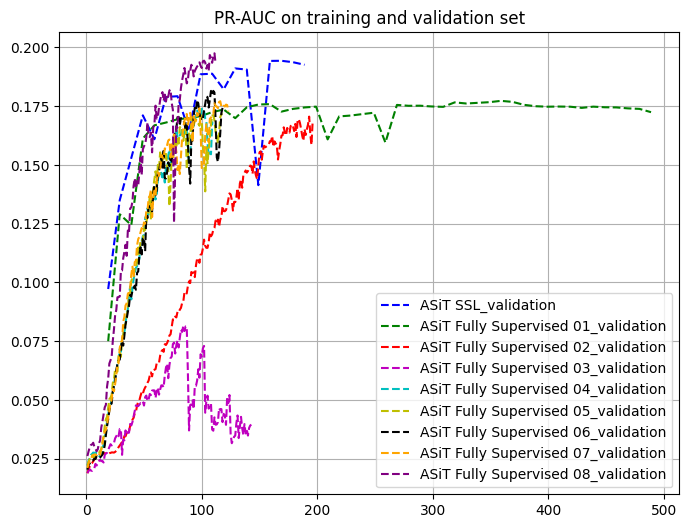

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

exp_list = [
    {"exp": "complete_asit_001", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "b", "label": "ASiT SSL"},
    {"exp": "asit_supervised_001", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "g", "label": "ASiT Fully Supervised 01"},
    {"exp": "asit_supervised_002", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "r", "label": "ASiT Fully Supervised 02"},
    {"exp": "asit_supervised_003", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "m", "label": "ASiT Fully Supervised 03"},
    {"exp": "asit_supervised_004", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "c", "label": "ASiT Fully Supervised 04"},
    {"exp": "asit_supervised_005", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "y", "label": "ASiT Fully Supervised 05"},
    {"exp": "asit_supervised_006", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "k", "label": "ASiT Fully Supervised 06"},
    {"exp": "asit_supervised_007", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "orange", "label": "ASiT Fully Supervised 07"},
    {"exp": "asit_supervised_008", "metrics_folder": "supervised_metrics", "version": "version_0", "color": "purple", "label": "ASiT Fully Supervised 08"},
]

dic_df = {}
for exp in exp_list:
    print(exp["exp"], os.listdir(os.path.join(exp["exp"],exp["metrics_folder"])))
    
    # Handle both single version (string) and multiple versions (list)
    versions = exp["version"] if isinstance(exp["version"], list) else [exp["version"]]
    
    # Load dataframes from all versions with version index
    dfs_list = []
    for version_idx, version in enumerate(versions):
        pathfile_exp = os.path.join(exp["exp"], exp["metrics_folder"], version, "metrics.csv")
        if os.path.exists(pathfile_exp):
            df = pd.read_csv(pathfile_exp)
            # Add version index: higher index = newer version (later in list)
            df['_version_idx'] = version_idx
            dfs_list.append(df)
            print(f"  Loaded {version}: {len(df)} rows")
        else:
            print(f"  Warning: {pathfile_exp} not found")
    
    if len(dfs_list) == 0:
        print(f"  Error: No valid metrics files found for {exp['exp']}")
        continue
    
    # Combine all dataframes
    if len(dfs_list) == 1:
        combined_df = dfs_list[0].drop(columns=['_version_idx'])
    else:
        # Find which epochs appear in which versions
        epoch_version_map = {}
        for version_idx, df in enumerate(dfs_list):
            unique_epochs = df['epoch'].unique()
            for epoch in unique_epochs:
                if epoch not in epoch_version_map:
                    epoch_version_map[epoch] = []
                epoch_version_map[epoch].append(version_idx)
        
        # Identify overlapping epochs (epochs in multiple versions)
        overlapping_epochs = {epoch: versions for epoch, versions in epoch_version_map.items() if len(versions) > 1}
        
        # Filter: For overlapping epochs, keep only ALL rows from newest version (highest version_idx)
        # For non-overlapping epochs, keep ALL rows from the version that has them
        filtered_rows = []
        for version_idx, df in enumerate(dfs_list):
            for _, row in df.iterrows():
                epoch = row['epoch']
                if epoch in overlapping_epochs:
                    # Overlapping epoch: only keep if this is the newest version
                    if version_idx == max(overlapping_epochs[epoch]):
                        filtered_rows.append(row)
                else:
                    # Non-overlapping epoch: keep all rows
                    filtered_rows.append(row)
        
        # Create combined dataframe from filtered rows
        combined_df = pd.DataFrame(filtered_rows).reset_index(drop=True)
        
        # Remove the temporary version index column
        combined_df = combined_df.drop(columns=['_version_idx'])
        
        # Sort by epoch for final output
        combined_df = combined_df.sort_values('epoch').reset_index(drop=True)
    
    dic_df[exp["exp"]] = combined_df
    print(f"  Combined: {len(combined_df)} rows")

plt.figure(figsize=(8, 6))
plt.subplot(111)
ini_epoch = 1
last_epoch = -1

for exp in exp_list:
    df_exp = dic_df[exp["exp"]]
    x, y = df_exp["epoch"], df_exp["val_map"]
    x = x[y.notna()]
    y = y[y.notna()]
    plt.plot(x.values[ini_epoch:last_epoch], y.values[ini_epoch:last_epoch], color=exp["color"], linestyle="--", label=f"{exp['label']}_validation")
    # x, y = df_exp["epoch"], df_exp["train_map_eval"]
    # x = x[y.notna()]
    # y = y[y.notna()]
    # plt.plot(x.values[ini_epoch:last_epoch], y.values[ini_epoch:last_epoch], color=exp["color"], linestyle="-", label=f"{exp['label']}_training")

plt.legend()
plt.title("PR-AUC on training and validation set")
plt.grid()

for exp in exp_list:
    print(f"{exp['label']}_validation: {dic_df[exp['exp']]['val_map'].max()}")